1. Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns


2. Loading Dataset

In [7]:
df = pd.read_csv ("cancer.csv")

3. Checking Dataset

In [8]:
# First 5 Rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [10]:
# Dataset Dimensions Rows and Columns
df.shape

(569, 31)

In [11]:
# Columns Names
df.columns.tolist()

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

In [13]:
# Printing DataTypes
df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


In [12]:
# Data Types and Memory Usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

4. Data Cleaning

In [14]:
# Checking Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


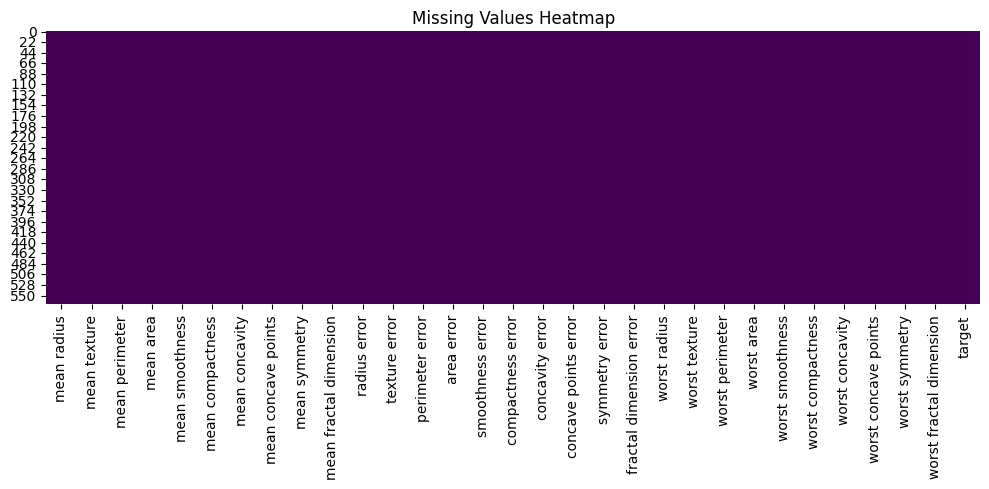

In [16]:
# Visualizing Missing Values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

In [17]:
# Handling missing values (choose strategy based on column type)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in [np.float64, np.int64]:
            # Fill numeric columns with median (robust to outliers)
            df[col] = df[col].fillna(df[col].median())
        else:
            # Fill categorical columns with mode
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:", df.isnull().sum().sum())


Missing values after cleaning: 0


In [18]:
# Check and remove duplicate rows
print("\n--- Duplicate Rows ---")
print("Number of duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


--- Duplicate Rows ---
Number of duplicates: 0
Shape after removing duplicates: (569, 31)


In [19]:

# 3.4 Standardize column names (lowercase, no spaces)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [21]:
# 3.5 Detect and handle outliers using IQR method
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\n--- Outlier Detection (IQR method) ---")
outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier Count"])
print(outlier_df)


--- Outlier Detection (IQR method) ---
                         Outlier Count
mean_radius                         14
mean_texture                         7
mean_perimeter                      13
mean_area                           25
mean_smoothness                      6
mean_compactness                    16
mean_concavity                      18
mean_concave_points                 10
mean_symmetry                       15
mean_fractal_dimension              15
radius_error                        38
texture_error                       20
perimeter_error                     38
area_error                          65
smoothness_error                    30
compactness_error                   28
concavity_error                     22
concave_points_error                19
symmetry_error                      27
fractal_dimension_error             28
worst_radius                        17
worst_texture                        5
worst_perimeter                     15
worst_area              

In [22]:
# Cap outliers instead of deleting rows (safer for small medical datasets)
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower_bound, upper_bound)

for col in ["trestbps", "chol", "thalach", "oldpeak"]:
    if col in df.columns:
        df[col] = cap_outliers(df[col])

print("\nOutliers capped for key numeric columns.")


Outliers capped for key numeric columns.


UNIVARIATE ANALYSIS

/tmp/ipykernel_2510/1107086779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette="Set2")


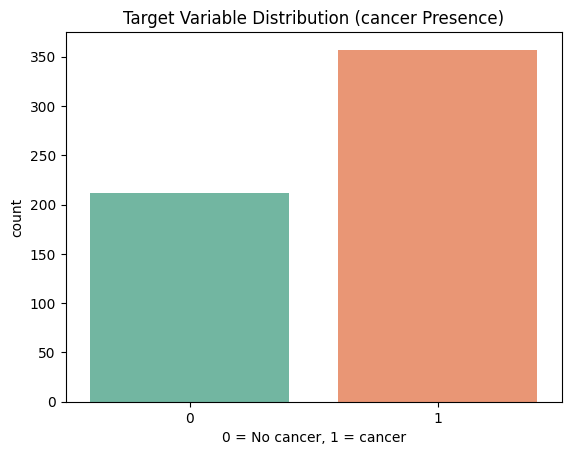


Target value counts:
 target
1    357
0    212
Name: count, dtype: int64

Target percentage:
 target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


In [24]:
# 4.1 Target variable distribution
target_col = "target" if "target" in df.columns else df.columns[-1]

plt.figure()
sns.countplot(x=target_col, data=df, palette="Set2")
plt.title("Target Variable Distribution (cancer Presence)")
plt.xlabel("0 = No cancer, 1 = cancer")
plt.show()

print("\nTarget value counts:\n", df[target_col].value_counts())
print("\nTarget percentage:\n", df[target_col].value_counts(normalize=True) * 100)

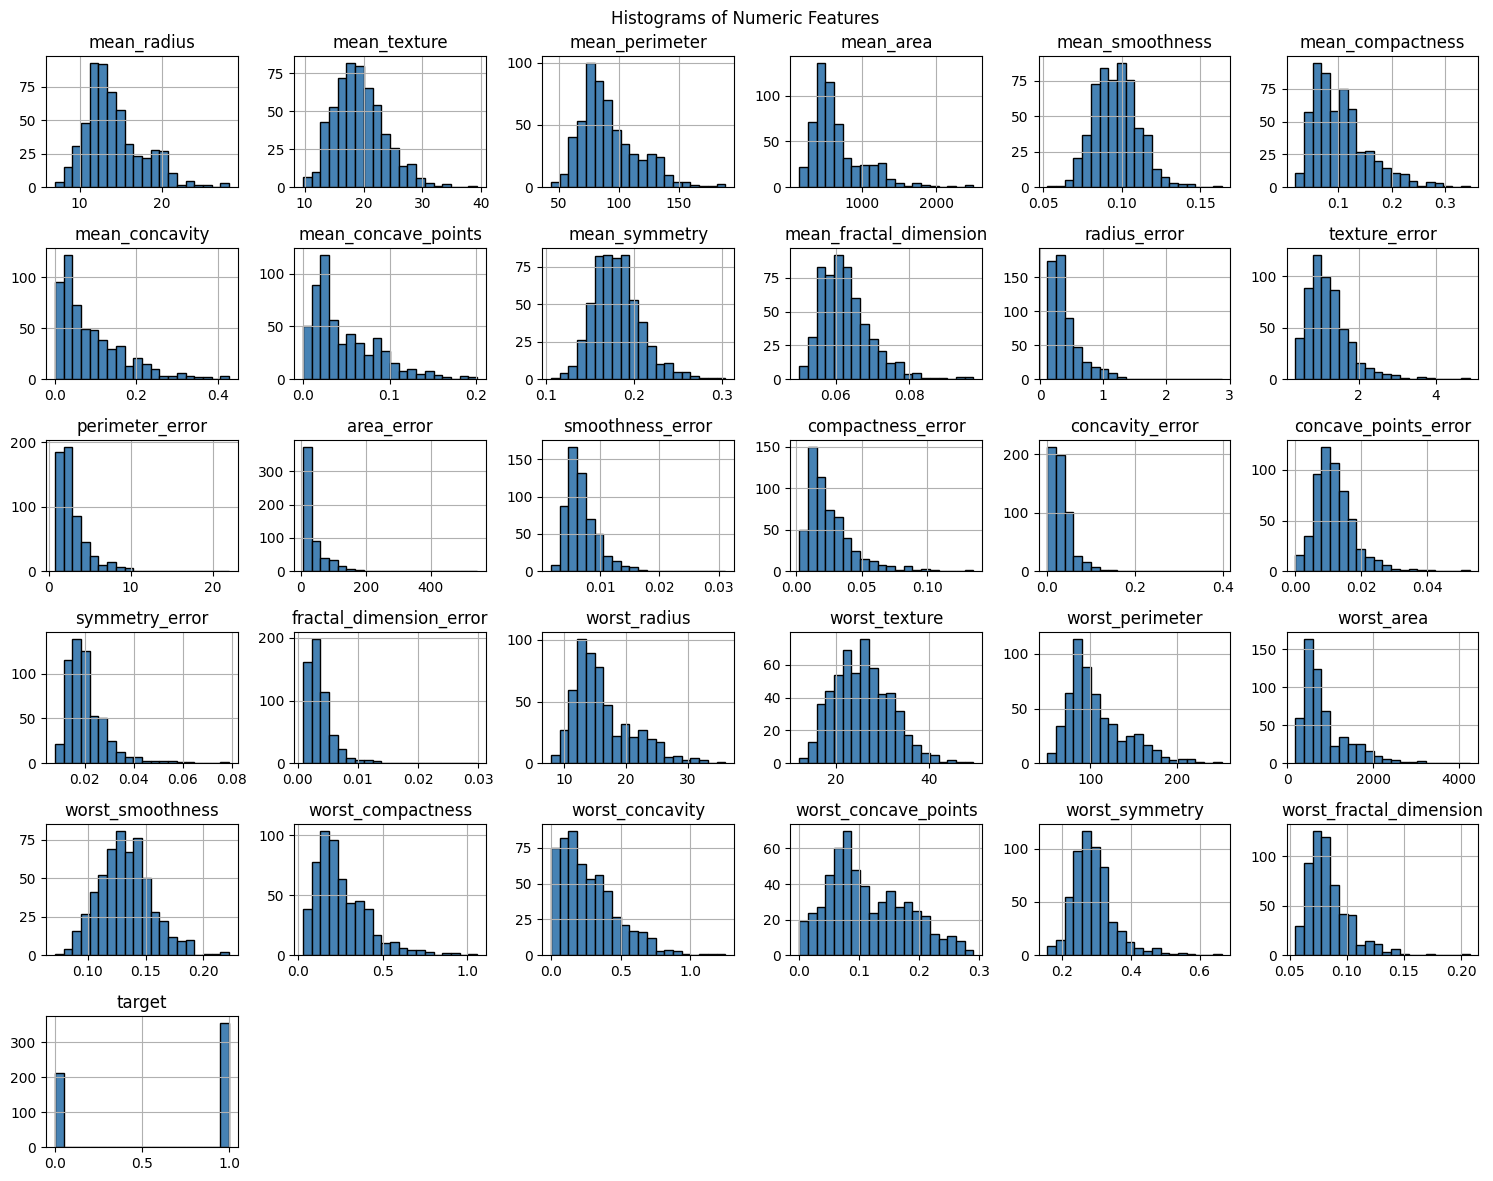

In [25]:
# 4.2 Distribution of all numeric features (histograms)
df[numeric_cols].hist(figsize=(15, 12), bins=20, color="steelblue", edgecolor="black")
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

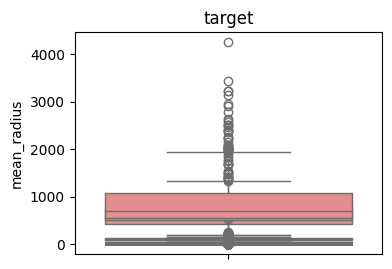

In [28]:
# 4.3 Boxplots to visualize spread/outliers per feature
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, 2)
    sns.boxplot(y=df[col], color="lightcoral")
    plt.title(col)
plt.tight_layout()
plt.show()

Multivariate Analysis

/tmp/ipykernel_2510/3363224586.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set3")
/tmp/ipykernel_2510/3363224586.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set3")
/tmp/ipykernel_2510/3363224586.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette="Set3")
/tmp/ipykernel_2510/3363224586.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` var

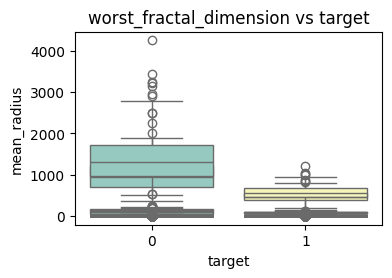

In [30]:
# 5.1 Numeric feature vs Target (boxplots)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    if col != target_col:
        plt.subplot(4, 4, 2)
        sns.boxplot(x=target_col, y=col, data=df, palette="Set3")
        plt.title(f"{col} vs {target_col}")
plt.tight_layout()
plt.show()

In [32]:
# 5.2 Categorical features vs Target (countplots)
categorical_like = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
categorical_like = [c for c in categorical_like if c in df.columns]

plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_like, 1):
    plt.subplot(3, 3, 1)
    sns.countplot(x=col, hue=target_col, data=df, palette="husl")
    plt.title(f"{col} vs {target_col}")
plt.tight_layout()
plt.show()

<Figure size 1500x1200 with 0 Axes>

 CORRELATION ANALYSIS

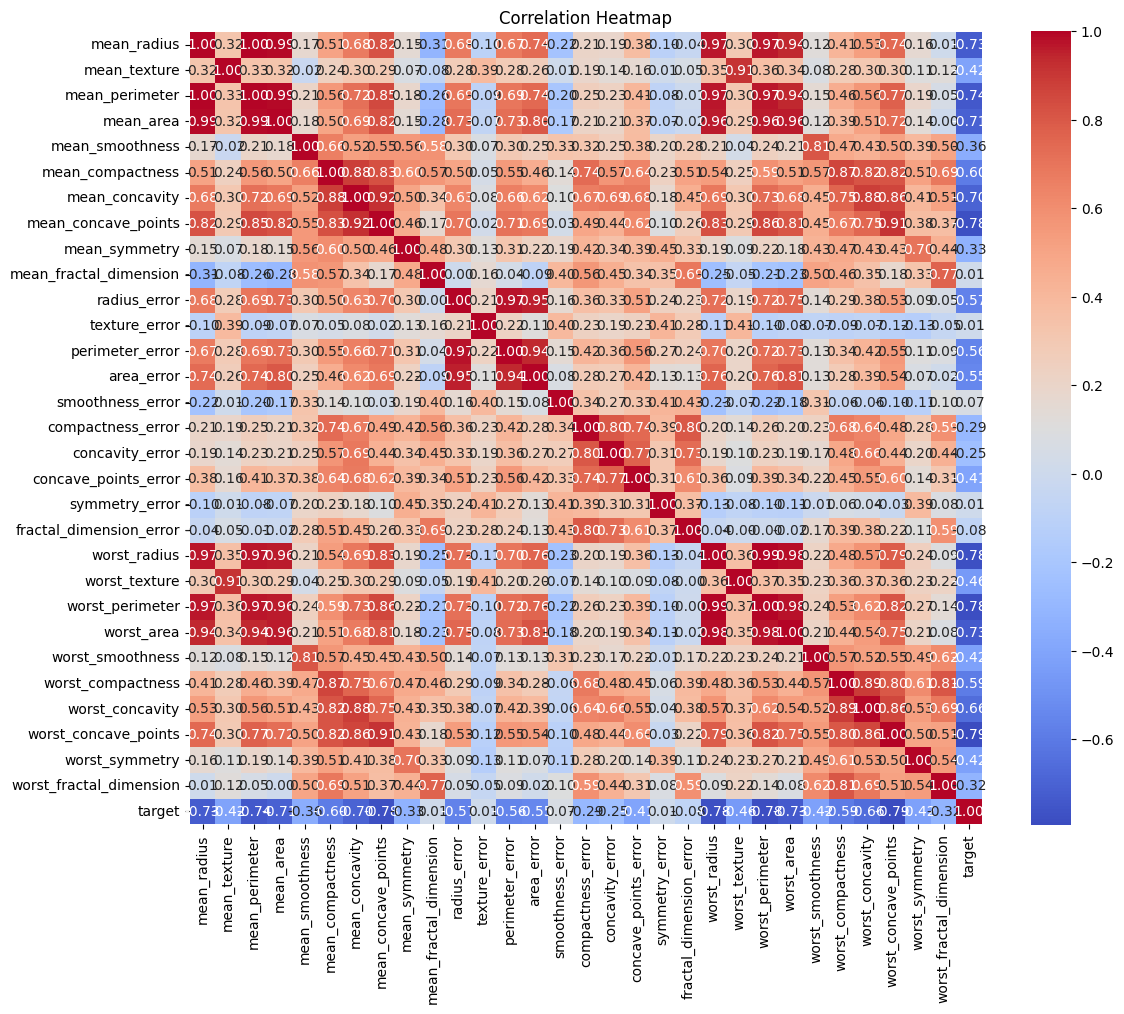


--- Top correlations with target ---
target                     1.000000
smoothness_error           0.067016
mean_fractal_dimension     0.012838
texture_error              0.008303
symmetry_error             0.006522
fractal_dimension_error   -0.077972
concavity_error           -0.253730
compactness_error         -0.292999
worst_fractal_dimension   -0.323872
mean_symmetry             -0.330499
mean_smoothness           -0.358560
concave_points_error      -0.408042
mean_texture              -0.415185
worst_symmetry            -0.416294
worst_smoothness          -0.421465
worst_texture             -0.456903
area_error                -0.548236
perimeter_error           -0.556141
radius_error              -0.567134
worst_compactness         -0.590998
mean_compactness          -0.596534
worst_concavity           -0.659610
mean_concavity            -0.696360
mean_area                 -0.708984
mean_radius               -0.730029
worst_area                -0.733825
mean_perimeter            

In [34]:
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("\n--- Top correlations with target ---")
if target_col in corr_matrix.columns:
    print(corr_matrix[target_col].sort_values(ascending=False))

7. ENCODING CATEGORICAL VARIABLES

In [35]:
label_encoders = {}
object_cols = df.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\nEncoded columns:", object_cols)


Encoded columns: []


 8. FEATURE SCALING

In [40]:
from sklearn.preprocessing import StandardScaler

# Clean up column names (lowercase, no extra spaces) — fixes most mismatches
df.columns = df.columns.str.strip().str.lower()

print("Your actual columns:", df.columns.tolist())

# Try the expected columns first
scale_cols = [c for c in ["age", "trestbps", "chol", "thalach", "oldpeak"] if c in df.columns]

# Fallback: if none matched, auto-select all numeric columns instead
if len(scale_cols) == 0:
    scale_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    print("No expected columns found — auto-selected numeric columns instead:", scale_cols)

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

print("\n--- Scaled Data Sample ---")
print(df_scaled[scale_cols].head())

Your actual columns: ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'perimeter_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'symmetry_error', 'fractal_dimension_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension', 'target']
No expected columns found — auto-selected numeric columns instead: ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'perimeter_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_point